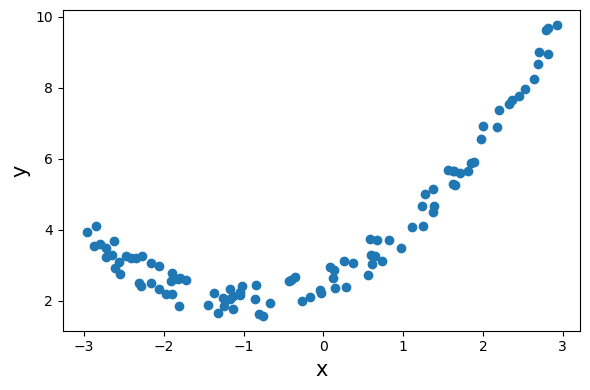

In [6]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
m = 100
x = 6 * np.random.rand(m,1) - 3
y=  0.5 * x**2 + x + 2 + np.random.rand(m,1)

# 데이터 분포
fig, ax = plt.subplots(figsize=(6,4))

ax.scatter(x,y)
ax.set_xlabel('x',fontsize=15)
ax.set_ylabel('y',fontsize=15)
plt.tight_layout()
plt.show()


In [7]:
# 선형 모델 적용
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x,y)

test_x = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# 예측
pred_y = model.predict(test_x)

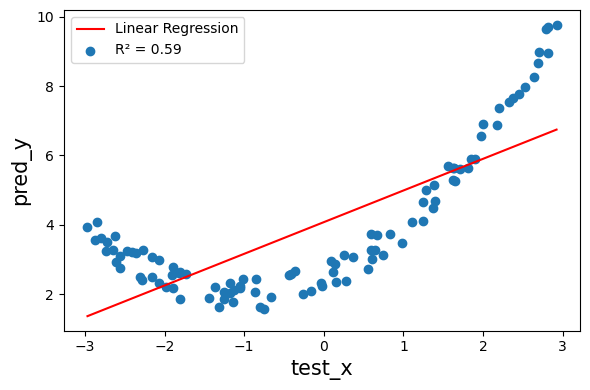

In [8]:
# 시각화

fig, ax = plt.subplots(figsize=(6,4))

ax.plot(test_x, pred_y, color='red')
ax.scatter(x,y)
ax.set_xlabel('test_x',fontsize=15)
ax.set_ylabel('pred_y',fontsize=15)
plt.legend(['Linear Regression', f'R² = {model.score(x,y):.2f}'])
plt.tight_layout()
plt.show()

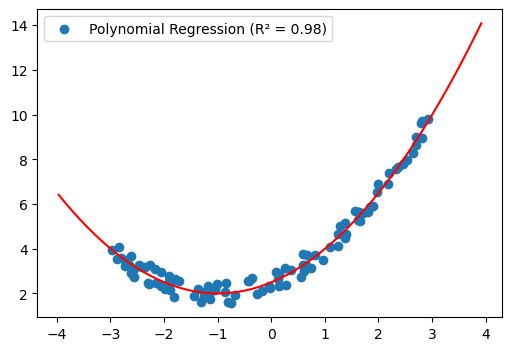

In [9]:
# 다항 회귀 모델 적용 / 시각화

p_x = np.hstack([x**2, x])
new_x = np.linspace(x.min()-1, x.max()+1, 100).reshape(-1,1)
lin_reg = LinearRegression()
lin_reg.fit(p_x,y)
y_pred = lin_reg.predict(np.hstack([new_x**2, new_x]))
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.plot(new_x, y_pred, color='red')
plt.legend([f'Polynomial Regression (R² = {lin_reg.score(p_x,y):.2f})'])
plt.show()

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


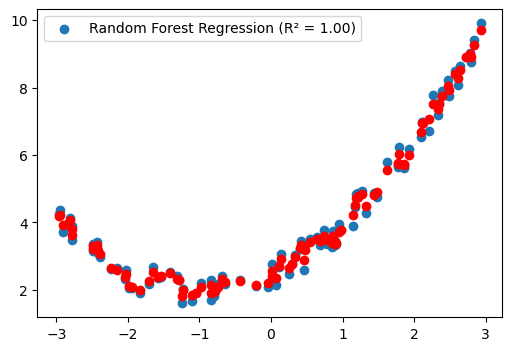

In [10]:
# 랜덤 포레스트 회귀 모델 적용 / 시각화

x = 6 * np.random.rand(m,1) - 3
y = 0.5 * x**2 + x + 2 + np.random.rand(m,1)

from sklearn.ensemble import RandomForestRegressor
random_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_model.fit(x,y)

y_pred = random_model.predict(x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Random Forest Regression (R² = {random_model.score(x,y):.2f})'])
plt.show()

c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


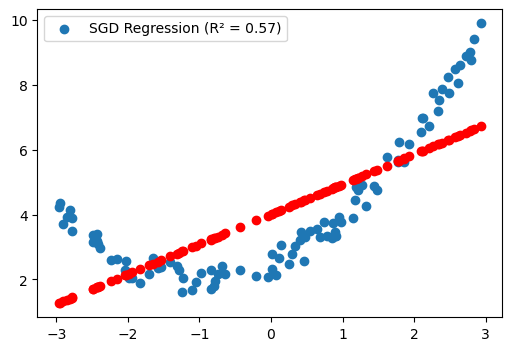

In [11]:
# 확률적 경사 하강법 모델 / 시각화
from sklearn.linear_model import SGDRegressor

sgd_model = SGDRegressor(max_iter=1000, random_state=42)
sgd_model.fit(x,y)
y_pred = sgd_model.predict(x)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'SGD Regression (R² = {sgd_model.score(x,y):.2f})'])
plt.show()


c:\Users\Playdata\AppData\Local\miniconda3\envs\new_01\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


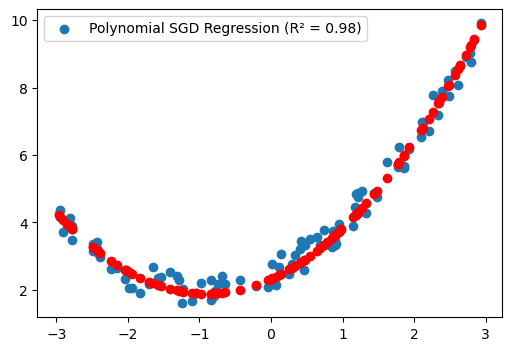

In [12]:
# 데이터 분포 직선변환
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly.fit_transform(x)

sgd_model.fit(x_poly, y)
y_pred = sgd_model.predict(x_poly)

fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x,y)
ax.scatter(x, y_pred, color='red')
plt.legend([f'Polynomial SGD Regression (R² = {sgd_model.score(x_poly,y):.2f})'])
plt.show()

In [13]:
# 과적합 (과소적합 과대적합)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
np.random.seed(42)

# 샘플 수 적게
n_samples = 20
# feature 수 많게 -> 과적합 유도
n_features = 100 # 컬럼수 또는 x의 수

x = np.random.randn(n_samples, n_features)
true_coef = np.zeros(n_features)  # 처음에는 모든 feature가 중요하지 않다고 가정
# 일부 feature만 중요하다고 가정
true_coef[:5] = [10, -7, 5, 3, -2]  #실제로 앞의 5개만 y에 영향을 줌 / 나머지는 노이즈
# true_coef 각 변수들의 가중치

# 타겟을 생성 y = 10*1 + (-7)*2 + 5*3 + ...
y = x @ true_coef + np.random.rand(n_samples) * 5  # 정규분포 노이즈 추가

# 일반 선형회귀
# 모델 학습
# 결정계수

from sklearn.linear_model import LinearRegression

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
print(f'R²: {model.score(x_train, y_train):.2f}')
model.predict(x_test)
print(f'R²: {model.score(x_test, y_test):.2f}')

R²: 1.00
R²: 0.40


In [14]:
# 모델이 노이즈까지 학습 
# 계수(가중치)가 비정상적으로 커짐 
# 규제로 해결 (Regularization)

# Ridge (L2)
    # loss = mse + sum(가중치**2)  --> 가중치 전체적으로 작게 만듬 , 모든 feature 유지, 안정적
# Lasso (L1)
    # loss = mse + sum(|가중치|)  --> 가중치 중 일부를 0으로 만듬, 자동 feature 선택 , 해석 용이

from sklearn.linear_model import Ridge, Lasso
ridge = Ridge(alpha=30)
ridge.fit(x_train, y_train)
print(f'Ridge R²: {ridge.score(x_train, y_train):.2f}')
print(f'Ridge R²: {ridge.score(x_test, y_test):.2f}')

lasso = Lasso(alpha=2)
lasso.fit(x_train, y_train)
print(f'Lasso R²: {lasso.score(x_train, y_train):.2f}')
print(f'Lasso R²: {lasso.score(x_test, y_test):.2f}')

Ridge R²: 0.94
Ridge R²: 0.38
Lasso R²: 0.94
Lasso R²: 0.55


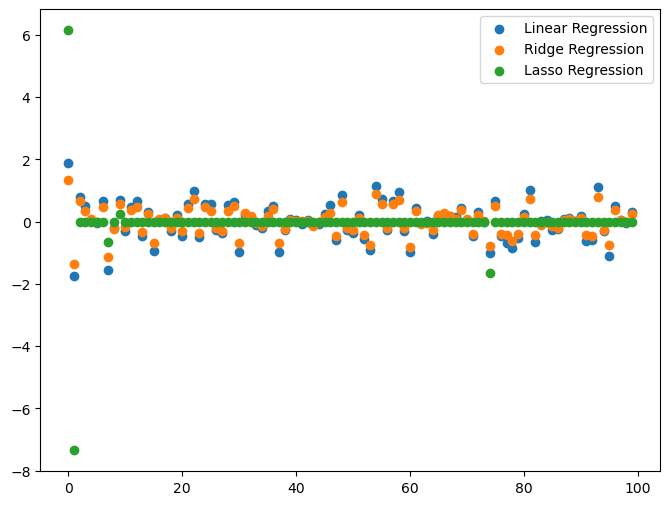

In [15]:
# 계수 비교
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(np.arange(len(model.coef_)), model.coef_, label='Linear Regression')
ax.scatter(np.arange(len(ridge.coef_)), ridge.coef_, label='Ridge Regression')
ax.scatter(np.arange(len(lasso.coef_)), lasso.coef_, label='Lasso Regression')

plt.legend()
plt.show()

# linear 계수 폭팔 (과적합) / ridge 전체적으로 작아짐 / lasso 일부 계수 0으로 만듬